In [1]:
from pathlib import Path
import sys
import os

current_dir = os.getcwd()
_ROOT = Path(current_dir).parents[0]
print(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
from utils.rl_core import compute_reinforce_plus_plus_distance_kernel_advantage, collate_trajectories

/Projects/spatial_training


/root/conda/envs/vlm_node_1016/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-18 09:00:17,771	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [32]:
import pickle
dbg_dir = "/Projects/spatial_training/dump/rl_eval/rpp_t_clipcov_ckpt_247/dbg/"
import glob
traj_pickle_files = glob.glob(dbg_dir+"rollout*")
trajs = []
for name in traj_pickle_files:
    try:
        with open(name,'rb') as f:
            traj = pickle.load(f)
            traj = [t[0] for t in traj]
            trajs+=traj
    except:
        pass

In [33]:
traj_batch = collate_trajectories(trajs)
print(traj_batch.shape)

torch.Size([116, 400])


In [34]:
from config_schema import RLAlgoConfig
conf = RLAlgoConfig(gamma=0.999,distance_kernel_sigma=1.3)
adv,rtn,baseline = compute_reinforce_plus_plus_distance_kernel_advantage(traj_batch['rewards'],traj_batch['response_mask'],distances=traj_batch['distance_to_goal'],config = conf)

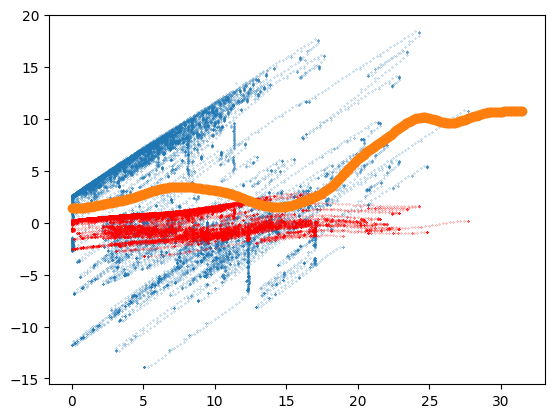

In [35]:
import matplotlib.pyplot as plt
import numpy as np
y = rtn[traj_batch['response_mask']>0]
x = traj_batch['distance_to_goal'][traj_batch['response_mask']>0]
z = adv[traj_batch['response_mask']>0]

plt.scatter(x,y,s=0.04)
plt.scatter(x,z,s=0.04,c='r')
plt.scatter(np.arange(len(baseline))*0.1,baseline)

In [31]:
a,_ = 1,

ValueError: not enough values to unpack (expected 2, got 1)

In [6]:
baseline.shape

torch.Size([292])